# Customer Churn Prediction

### Problem Statement

The goal of this project is to predict whether a customer will leave the company's service based on customer information. This helps businesses identify at-risk customers and improve customer retention.

### Import Libraries
Importing the required libraries for data analysis and visualization.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Loading the dataset.

In [3]:
df=pd.read_csv("data/Telco_Customer_Churn.csv")
df_cleaned=df.copy()


In [4]:
df.shape

(7043, 21)

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [7]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [10]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
(df["TotalCharges"]==" ").sum()

np.int64(11)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["customerID"].duplicated().sum()

np.int64(0)

In [16]:
# Target
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [17]:
# Customer demographics
df["gender"].value_counts()


gender
Male      3555
Female    3488
Name: count, dtype: int64

In [18]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [19]:
# Customer relationship
df["Partner"].value_counts()

Partner
No     3641
Yes    3402
Name: count, dtype: int64

In [20]:
df["Dependents"].value_counts()

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

In [21]:
# Services
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [22]:
# Business-related features
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [23]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [24]:
# Billing
df["PaperlessBilling"].value_counts()

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

In [25]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [26]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


In [27]:
(df_cleaned["TotalCharges"] == " ").sum()

np.int64(11)

In [28]:
df_cleaned["TotalCharges"] = pd.to_numeric(df_cleaned["TotalCharges"],errors="coerce")

In [29]:
df_cleaned["TotalCharges"].dtype

dtype('float64')

In [30]:
df_cleaned.dropna(inplace=True)

In [31]:
df_cleaned.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [32]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [34]:
#splitting numerical and categorical features
num_cols = df_cleaned.select_dtypes(include=["int64","float64"]).columns
catg_cols = df_cleaned.select_dtypes(include=["object"]).columns
print(num_cols)
print(catg_cols)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')


<Axes: xlabel='Churn', ylabel='count'>

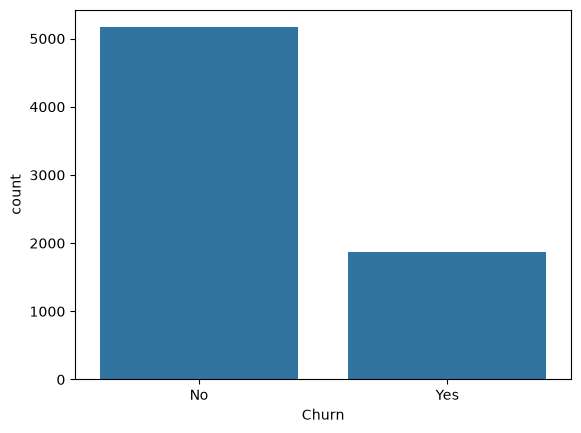

In [ ]:
#target distribution
sns.countplot( x="Churn",data=df_cleaned)

In [36]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

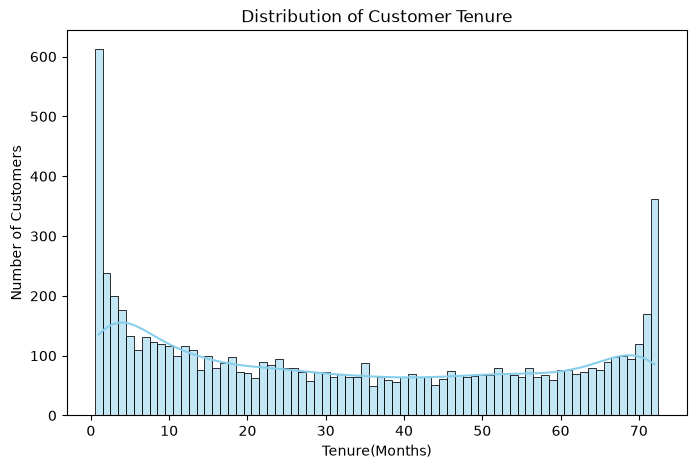

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_cleaned,x="tenure",bins=30,kde=True,discrete=True,color="skyblue")
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure(Months)")
plt.ylabel("Number of Customers")
plt.show()

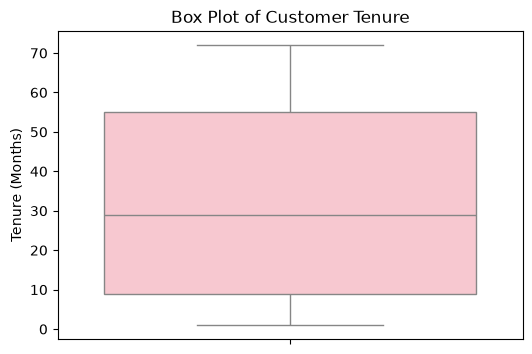

In [39]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df_cleaned["tenure"],color="pink")
plt.title("Box Plot of Customer Tenure")
plt.ylabel("Tenure (Months)")
plt.show()

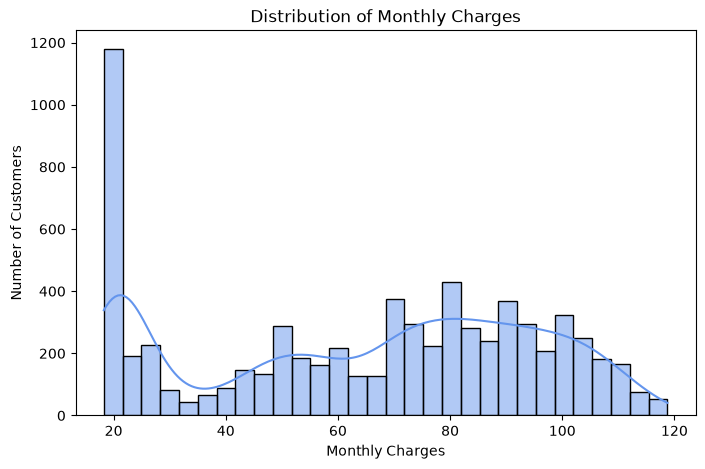

In [42]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_cleaned,x="MonthlyCharges",bins=30,kde=True,color="cornflowerblue")
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

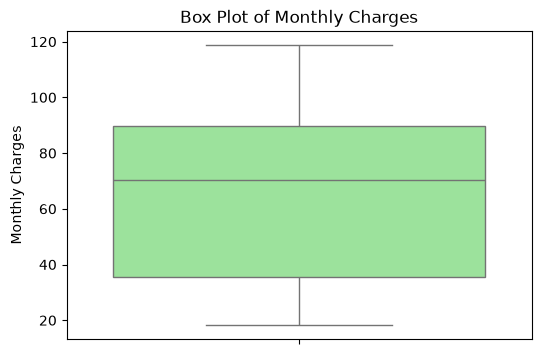

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df_cleaned["MonthlyCharges"],color="lightgreen")
plt.title("Box Plot of Monthly Charges")
plt.ylabel("Monthly Charges")
plt.show()

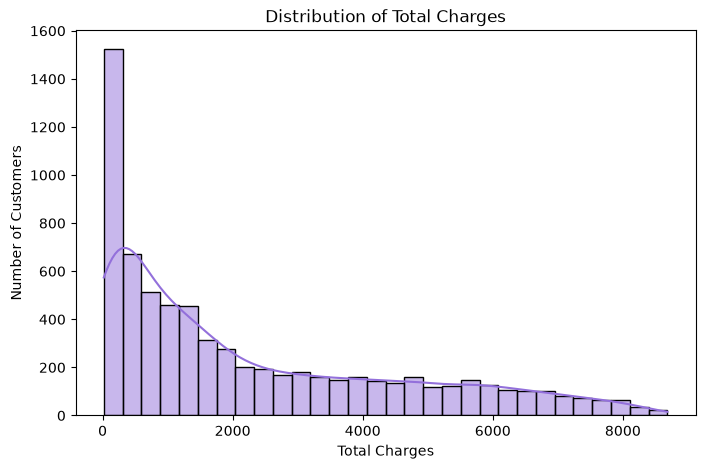

In [44]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_cleaned,x="TotalCharges",bins=30,kde=True,color="mediumpurple") #taking different colors from doc.
plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")
plt.show()

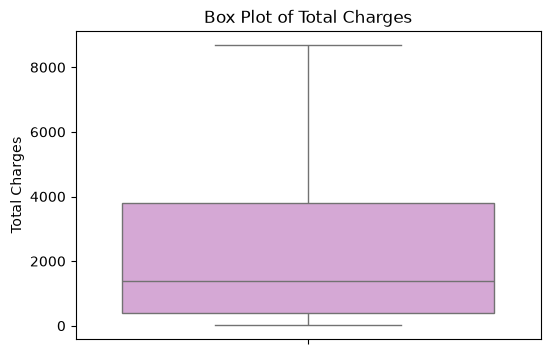

In [45]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df_cleaned["TotalCharges"],color="plum")
plt.title("Box Plot of Total Charges")
plt.ylabel("Total Charges")
plt.show()

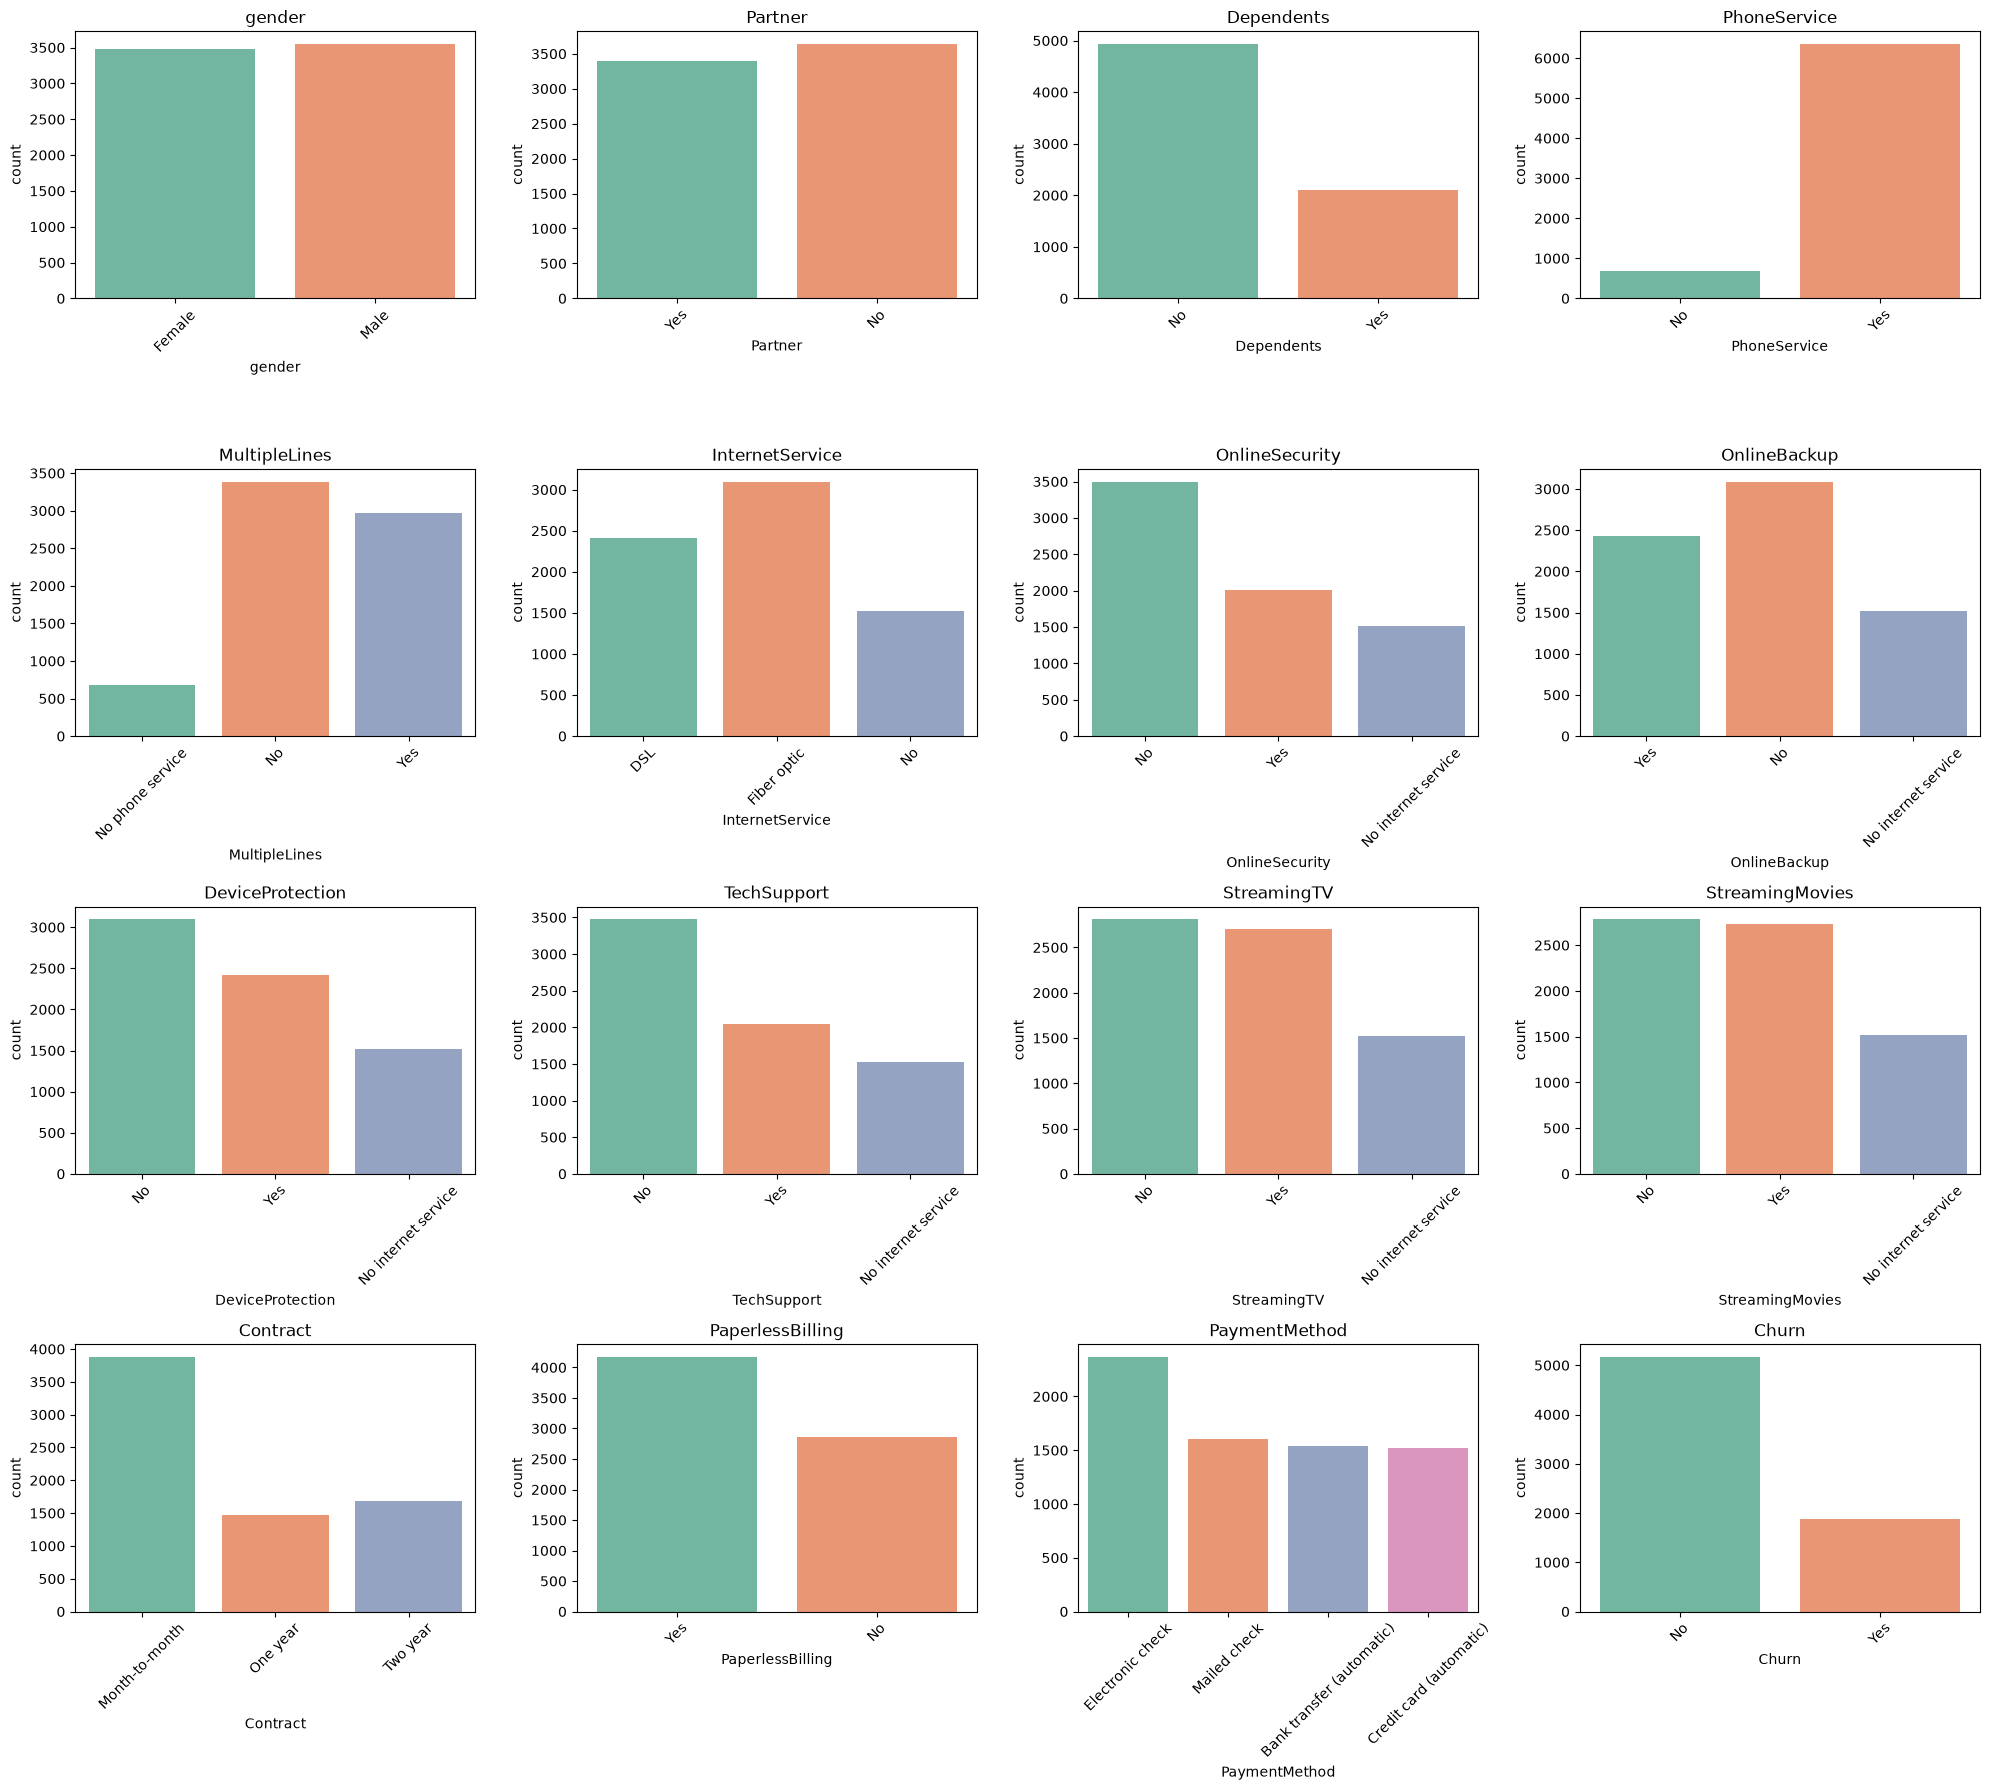

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

catg_cols = df_cleaned.select_dtypes(include="object").columns
cat_cols = [col for col in catg_cols if col != "customerID"]

fig, axes = plt.subplots(4,4,figsize=(20, 18))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(data=df_cleaned,x=col,hue=col,palette="Set2",ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

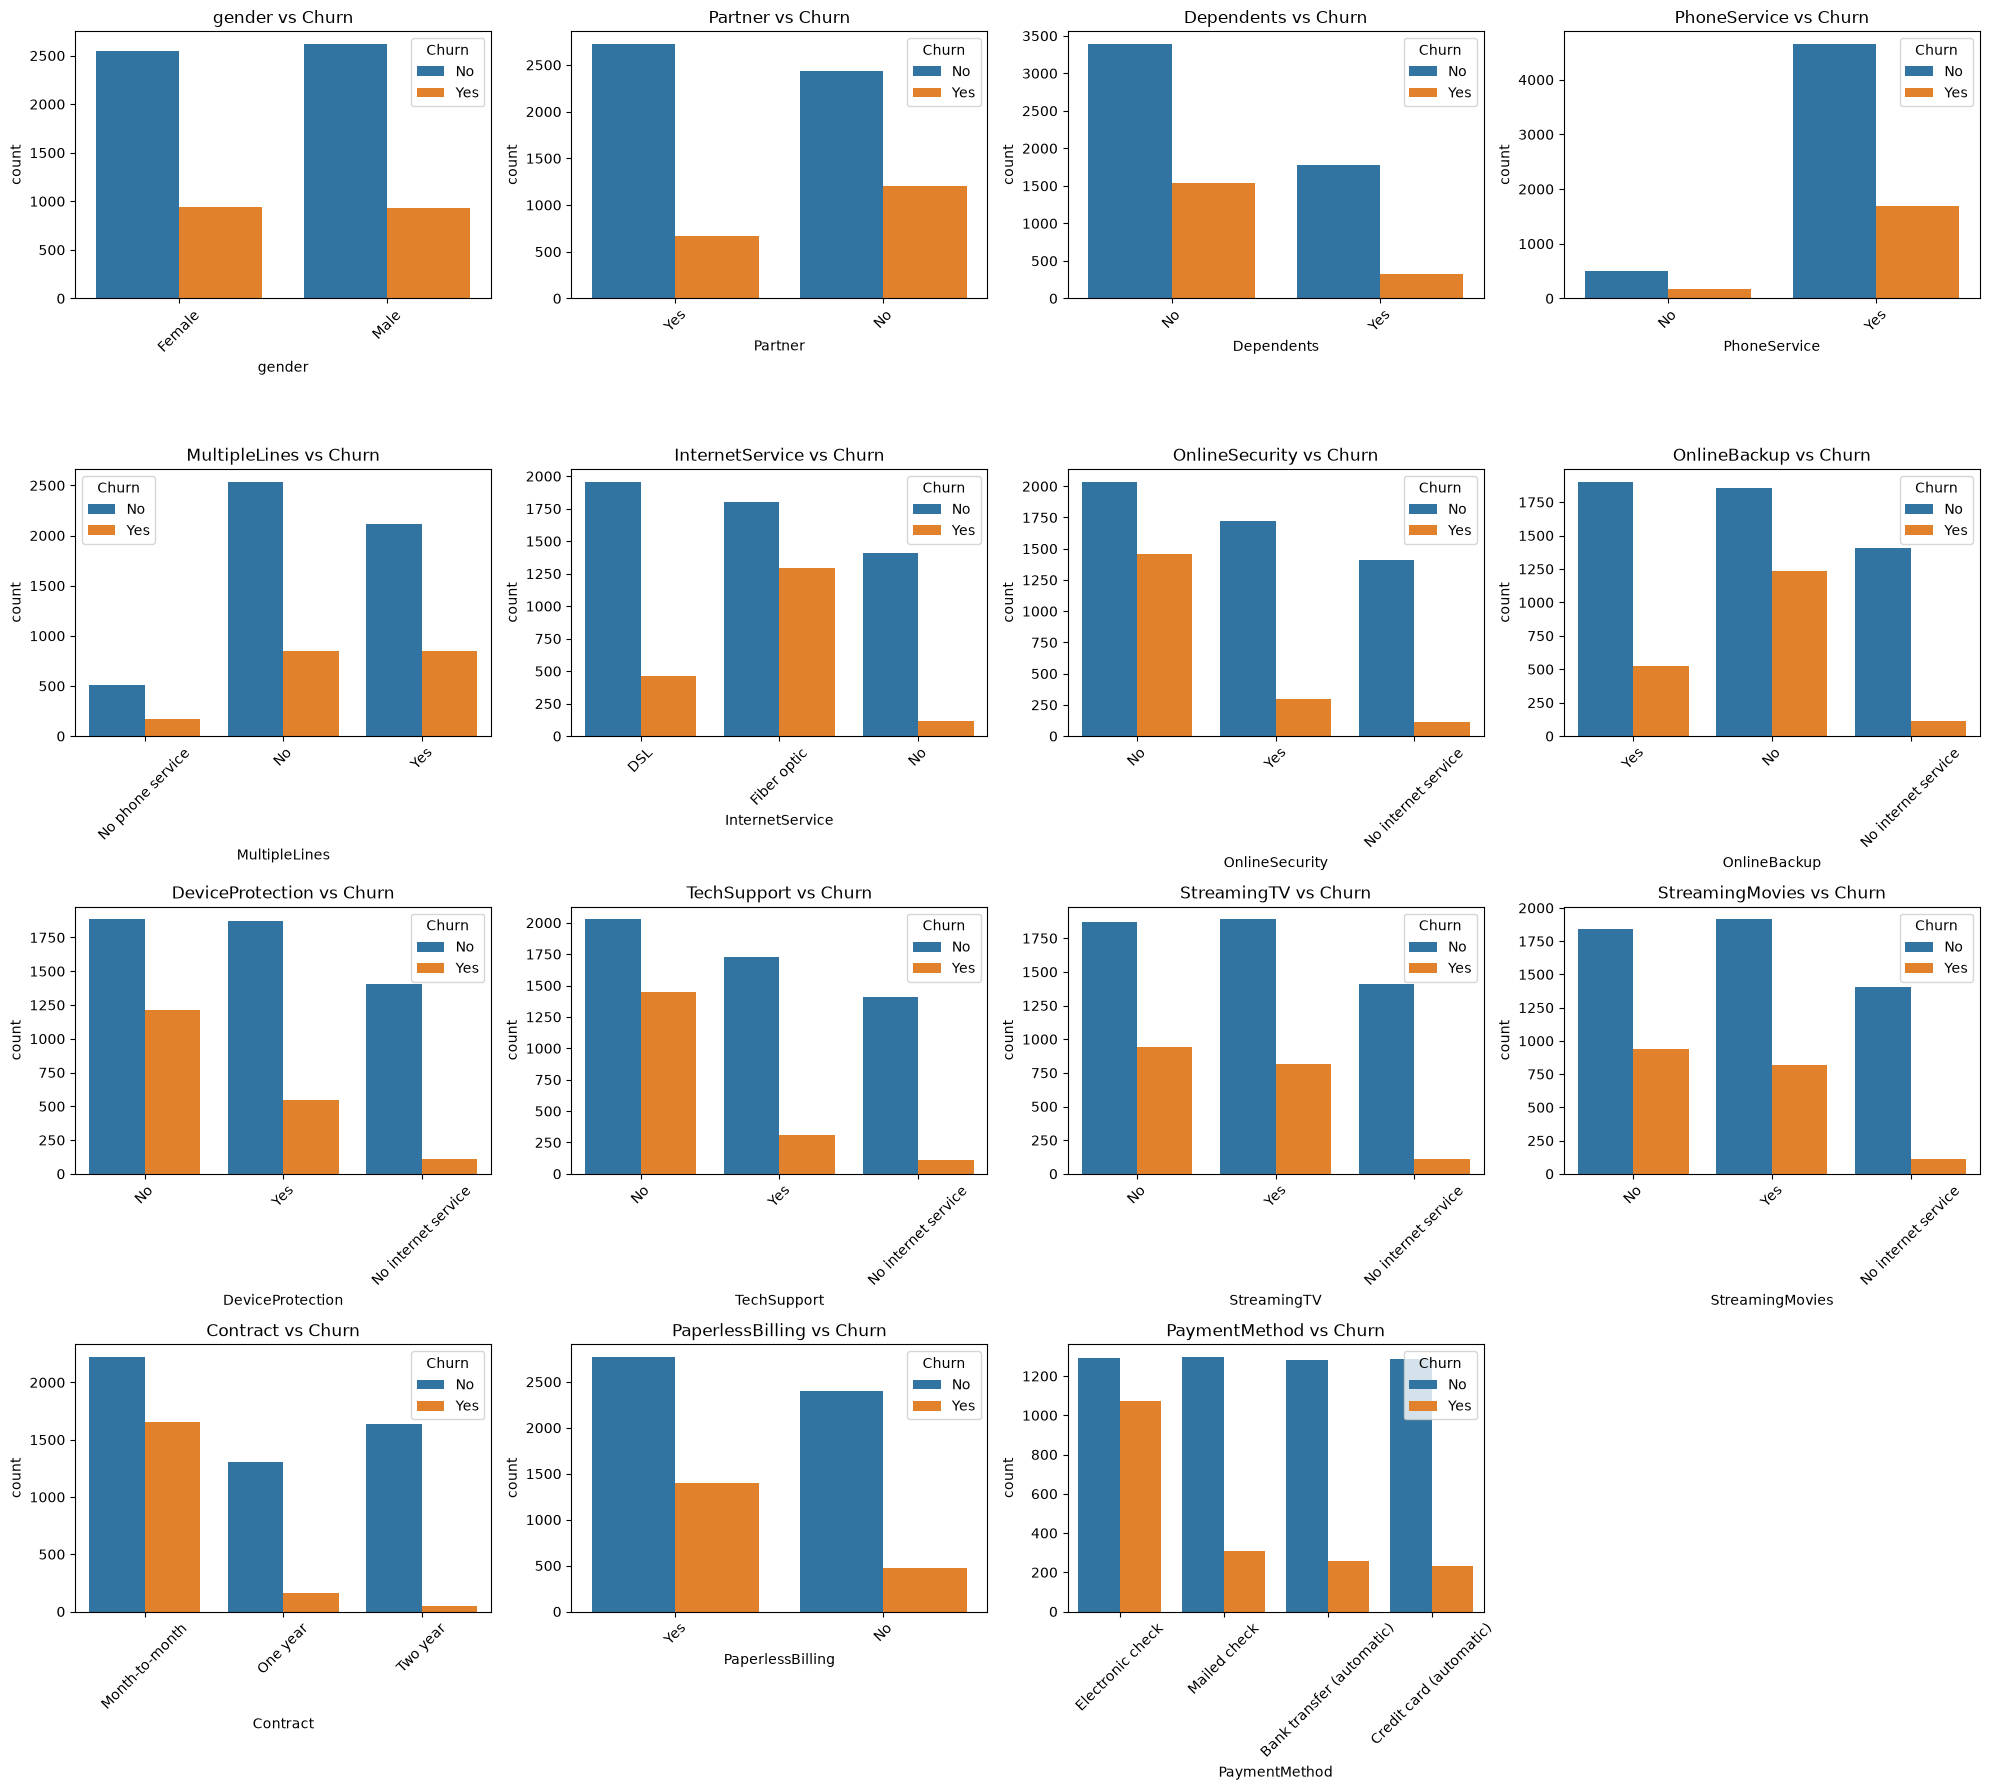

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
#Excluding customerID and Churn from feature list
cat_cols = [col for col in df_cleaned.select_dtypes(include=["object"]).columns
            if col not in ["customerID", "Churn"]]

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(data=df_cleaned,x=col,hue="Churn",ax=axes[i])
    axes[i].set_title(f"{col} vs Churn")
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplots
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [52]:
for col in cat_cols:
    print(f"\n{'='*50}")
    print(f"{col} vs Churn (%)")
    print(
        pd.crosstab(
            df_cleaned[col],
            df_cleaned["Churn"],
            normalize="index"
        ).mul(100).round(2)
    )


gender vs Churn (%)
Churn      No    Yes
gender              
Female  73.04  26.96
Male    73.80  26.20

Partner vs Churn (%)
Churn       No    Yes
Partner              
No       67.02  32.98
Yes      80.28  19.72

Dependents vs Churn (%)
Churn          No    Yes
Dependents              
No          68.72  31.28
Yes         84.47  15.53

PhoneService vs Churn (%)
Churn            No    Yes
PhoneService              
No            75.00  25.00
Yes           73.25  26.75

MultipleLines vs Churn (%)
Churn                No    Yes
MultipleLines                 
No                74.92  25.08
No phone service  75.00  25.00
Yes               71.35  28.65

InternetService vs Churn (%)
Churn               No    Yes
InternetService              
DSL              81.00  19.00
Fiber optic      58.11  41.89
No               92.57   7.43

OnlineSecurity vs Churn (%)
Churn                   No    Yes
OnlineSecurity                   
No                   58.22  41.78
No internet service  92.57   7.

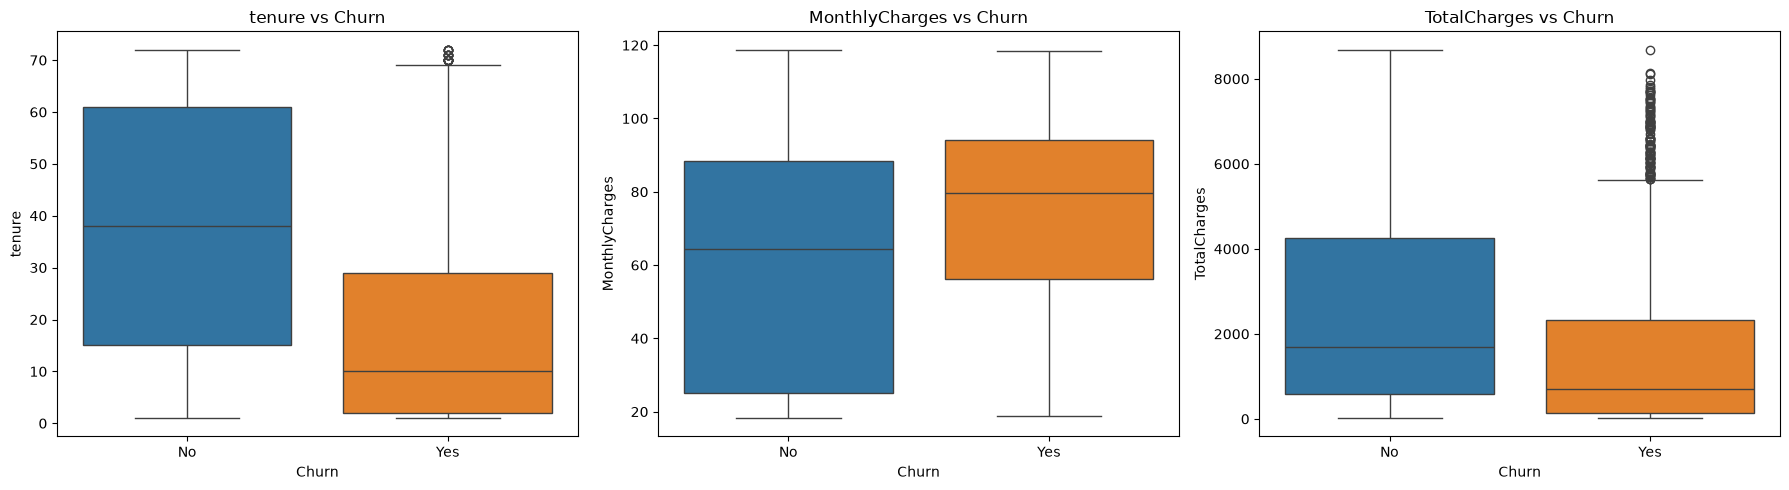

In [54]:
num_cols = ["tenure","MonthlyCharges","TotalCharges"]
fig, axes = plt.subplots(1,3,figsize=(18,5))
for i, col in enumerate(num_cols):
    sns.boxplot(data=df_cleaned,x="Churn",y=col,hue="Churn",ax=axes[i])
    axes[i].set_title(f"{col} vs Churn")

plt.tight_layout()
plt.show()

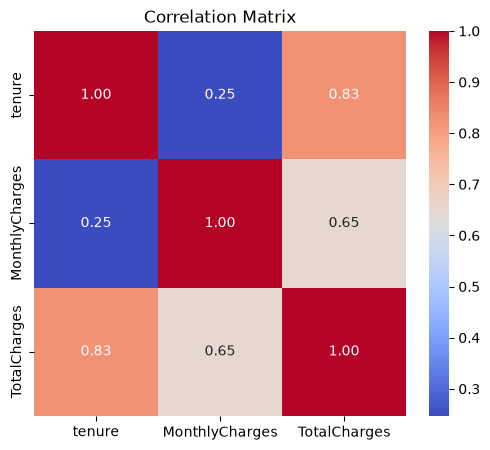

In [55]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
corr = df_cleaned[num_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [56]:
df_cleaned.to_csv("data/cleaned_telco_churn.csv", index=False)